In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import zscore

In [25]:
df = pd.read_csv("sudan.csv")

if not {"YEAR", "DOY"}.issubset(df.columns):
    # NASA files may include metadata lines before the actual header.
    df = pd.read_csv("sudan.csv", skiprows=14)

required_cols = {"YEAR", "DOY"}
if not required_cols.issubset(df.columns):
    raise ValueError(f"Missing required columns after load: {required_cols - set(df.columns)}")

df["Country"] = "Sudan"
print(f"Loaded sudan.csv with shape {df.shape}")

Loaded sudan.csv with shape (4108, 13)


In [26]:
df["date"] = pd.to_datetime(df["YEAR"] * 1000 + df["DOY"], format="%Y%j")
df["Month"] = df["date"].dt.month

## Missing values and duplicate rows
Replace NASA sentinel values before running statistics, then check for duplicates and remove them.

In [27]:
df.replace(-999, np.nan, inplace=True)

dup_count = df.duplicated().sum()
print("Duplicate rows (all columns):", dup_count)

if {"YEAR", "DOY"}.issubset(df.columns):
    dup_year_doy = df.duplicated(subset=["YEAR", "DOY"], keep=False).sum()
    print("Rows sharing YEAR+DOY keys:", dup_year_doy)

df = df.drop_duplicates()
print("Rows after deduplication:", len(df))

Duplicate rows (all columns): 0
Rows sharing YEAR+DOY keys: 0
Rows after deduplication: 4108


## Summary statistics
Numeric summary for all climate variables.

In [28]:
numeric_cols = df.select_dtypes(include=[np.number]).columns
summary_stats = df[numeric_cols].describe().T
summary_stats

,count,mean,std,min,25%,50%,75%,max
YEAR,4108.0,2020.131451,3.248907,2015.00,2017.0000,2020.00,2023.0000,2026.00
DOY,4108.0,180.121227,106.294767,1.00,86.0000,179.00,272.0000,366.00
T2M,4108.0,16.068500,1.898050,10.03,14.8200,16.04,17.3600,21.53
T2M_MAX,4108.0,23.199175,2.751471,15.65,21.1100,22.74,25.1700,30.93
T2M_MIN,4108.0,10.227544,2.607256,1.17,8.4175,10.99,12.2200,15.68
T2M_RANGE,4108.0,12.971631,3.821239,3.56,9.8300,13.03,16.0200,23.24
PRECTOTCORR,4108.0,3.633795,6.289061,0.00,0.0200,0.82,4.5800,82.30
RH2M,4108.0,68.408588,14.735838,14.42,59.0300,71.12,80.8025,91.93
WS2M,4108.0,1.979998,0.689093,0.46,1.4075,1.97,2.4800,4.13
WS2M_MAX,4108.0,3.575246,1.123721,0.79,2.7200,3.53,4.3700,7.49


### Summary interpretation
The summary table above provides the central tendency and spread for key variables (temperature, rainfall, humidity, wind, and pressure).
Temperature range and variability should be interpreted together with seasonality to distinguish baseline patterns from short-term swings.
Extremes (for example T2M_MAX near 30.93C and T2M_MIN near 1.17C) appear plausible for variability in Sudann climate conditions.

## Missing-value report
Missing counts and percentages by column.

In [29]:
missing_count = df.isna().sum()
missing_pct = (missing_count / len(df)) * 100

print("Missing count by column:")
print(missing_count.sort_values(ascending=False))
print("\nMissing percent by column:")
print(missing_pct.sort_values(ascending=False).round(2))

high_missing = missing_pct[missing_pct > 5].sort_values(ascending=False)
if high_missing.empty:
    print("\nNo columns exceed 5% missing values.")
else:
    print("\nColumns above 5% missing:")
    print(high_missing.round(2))

Missing count by column:
YEAR           0
DOY            0
T2M            0
T2M_MAX        0
T2M_MIN        0
T2M_RANGE      0
PRECTOTCORR    0
RH2M           0
WS2M           0
WS2M_MAX       0
PS             0
QV2M           0
Country        0
date           0
Month          0
dtype: int64

Missing percent by column:
YEAR           0.0
DOY            0.0
T2M            0.0
T2M_MAX        0.0
T2M_MIN        0.0
T2M_RANGE      0.0
PRECTOTCORR    0.0
RH2M           0.0
WS2M           0.0
WS2M_MAX       0.0
PS             0.0
QV2M           0.0
Country        0.0
date           0.0
Month          0.0
dtype: float64

No columns exceed 5% missing values.


### Missing-value interpretation
Columns above 5% missing (if present) should be treated cautiously because they can bias trend, seasonality, and correlation estimates.
Low missingness improves confidence in downstream analysis; higher missingness would require stronger imputation or feature exclusion decisions.

## Outlier detection
Decision: retain outlier rows by default because true climate extremes can represent real weather events, not errors. If any variable shows impossible physical values, flag and handle those records separately.

In [30]:
cols = ["T2M", "T2M_MAX", "T2M_MIN", "PRECTOTCORR", "RH2M", "WS2M", "WS2M_MAX"]
z = np.abs(zscore(df[cols], nan_policy="omit"))
outlier_rows = (z > 3).any(axis=1)
print("Outlier rows:", outlier_rows.sum())
print("Outliers by variable:", (z > 3).sum(axis=0))

Outlier rows: 132
Outliers by variable: [ 3  0 18 95 13  3  5]


## Handle remaining missing values
Decision used in this notebook:
- Drop rows where more than 30% of columns are missing.
- Apply forward-fill to core weather variables (T2M, T2M_MAX, T2M_MIN, PRECTOTCORR, RH2M, WS2M, WS2M_MAX).
This balances data retention with quality control for downstream analysis.

In [31]:
row_missing_pct = df.isna().mean(axis=1) * 100
rows_to_drop = row_missing_pct > 30
print("Rows dropped for >30% missing values:", rows_to_drop.sum())
df = df.loc[~rows_to_drop].copy()

df[cols] = df[cols].ffill()
print("Remaining missing values in weather columns after ffill:")
print(df[cols].isna().sum())

import os
os.makedirs("data", exist_ok=True)
df.to_csv("data/sudan_clean.csv", index=False)
print("Saved cleaned file to data/sudan_clean.csv")

Rows dropped for >30% missing values: 0
Remaining missing values in weather columns after ffill:
T2M            0
T2M_MAX        0
T2M_MIN        0
PRECTOTCORR    0
RH2M           0
WS2M           0
WS2M_MAX       0
dtype: int64
Saved cleaned file to data/sudan_clean.csv


## Time series analysis
The next two charts show monthly average temperature and monthly total rainfall across 2015-2026, with annotations for warmest/coolest temperature months and top peak-rain months.

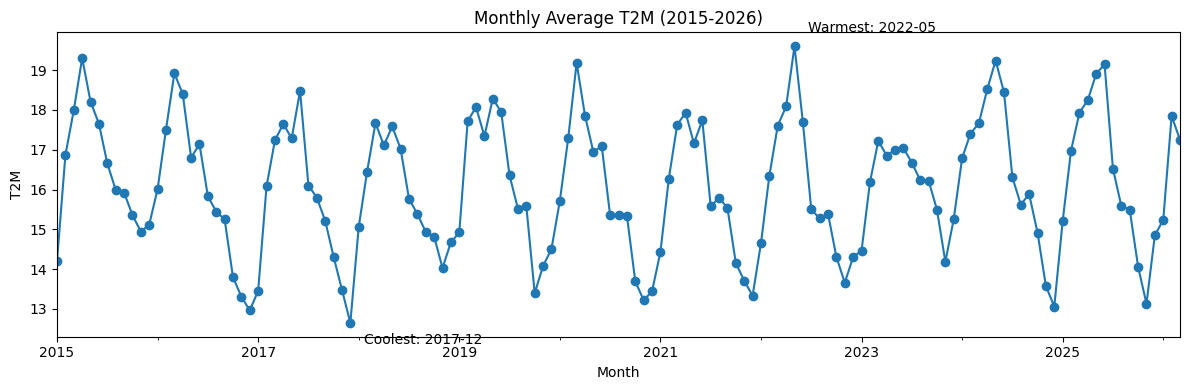

In [32]:
monthly_temp_ts = df.set_index("date").resample("MS")["T2M"].mean()
ax = monthly_temp_ts.plot(
    marker="o",
    figsize=(12, 4),
    title="Monthly Average T2M (2015-2026)"
)

warm_date = monthly_temp_ts.idxmax()
cool_date = monthly_temp_ts.idxmin()
ax.annotate(
    f"Warmest: {warm_date:%Y-%m}",
    xy=(warm_date, monthly_temp_ts.loc[warm_date]),
    xytext=(10, 10),
    textcoords="offset points"
    )
ax.annotate(
    f"Coolest: {cool_date:%Y-%m}",
    xy=(cool_date, monthly_temp_ts.loc[cool_date]),
    xytext=(10, -15),
    textcoords="offset points"
    )

plt.xlabel("Month")
plt.ylabel("T2M")
plt.tight_layout()
plt.show()

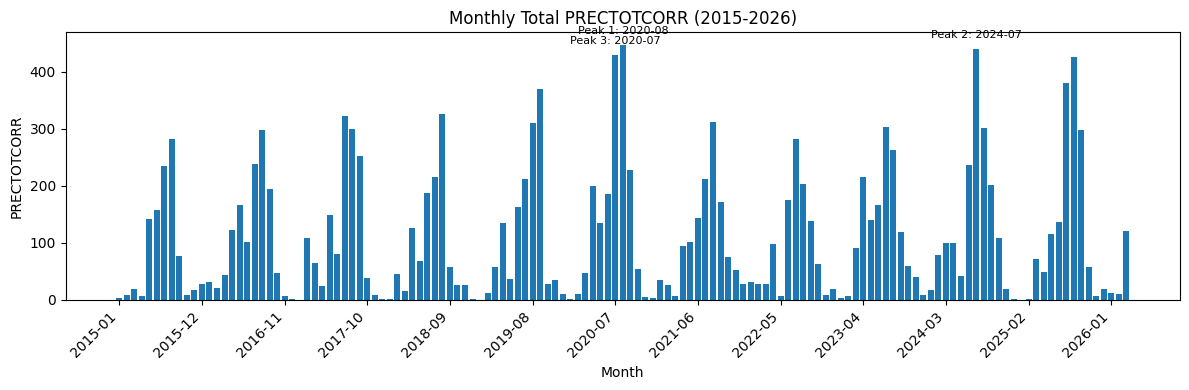

In [33]:
monthly_rain_ts = df.set_index("date").resample("MS")["PRECTOTCORR"].sum()
x = np.arange(len(monthly_rain_ts))
labels = monthly_rain_ts.index.strftime("%Y-%m")

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(x, monthly_rain_ts.values)
ax.set_title("Monthly Total PRECTOTCORR (2015-2026)")

peak_months = monthly_rain_ts.nlargest(3).sort_values(ascending=False)
for i, (dt, val) in enumerate(peak_months.items(), start=1):
    idx = monthly_rain_ts.index.get_loc(dt)
    ax.annotate(
        f"Peak {i}: {dt:%Y-%m}",
        xy=(idx, val),
        xytext=(0, 8),
        textcoords="offset points",
        ha="center",
        fontsize=8
    )

tick_step = max(1, len(x) // 12)
ax.set_xticks(x[::tick_step])
ax.set_xticklabels(labels[::tick_step], rotation=45, ha="right")
plt.xlabel("Month")
plt.ylabel("PRECTOTCORR")
plt.tight_layout()
plt.show()

### Time-series interpretation
The monthly T2M line shows a clear repeating annual cycle with moderate year-to-year variation across 2015-2026.
The annotated warmest and coolest months help reveal seasonal contrast and year-to-year shifts in thermal conditions.
Rainfall peaks identify likely rainy-season windows, while unusually large spikes may indicate exceptional wet events.

## Correlation and relationships
Inspect the heatmap and scatter plots, then identify the three strongest correlations in a markdown note.

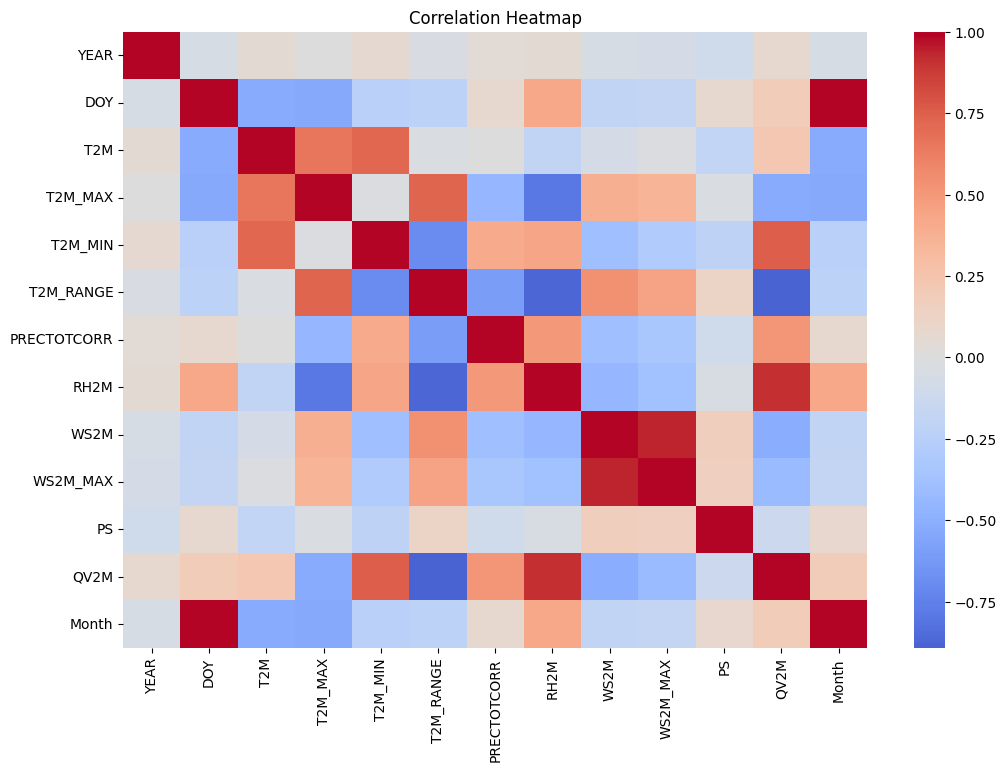

In [34]:
num_df = df.select_dtypes(include=[np.number])
plt.figure(figsize=(12, 8))
sns.heatmap(num_df.corr(), cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.show()

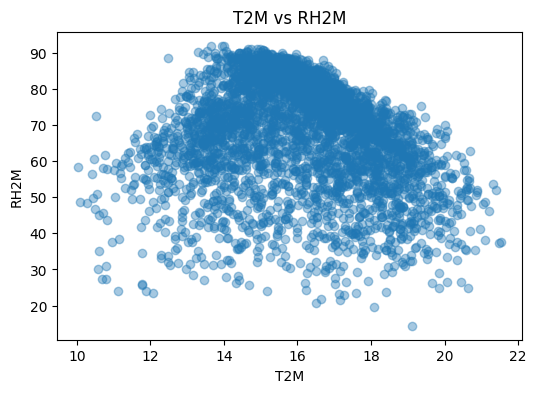

In [35]:
plt.figure(figsize=(6, 4))
plt.scatter(df["T2M"], df["RH2M"], alpha=0.4)
plt.xlabel("T2M")
plt.ylabel("RH2M")
plt.title("T2M vs RH2M")
plt.show()

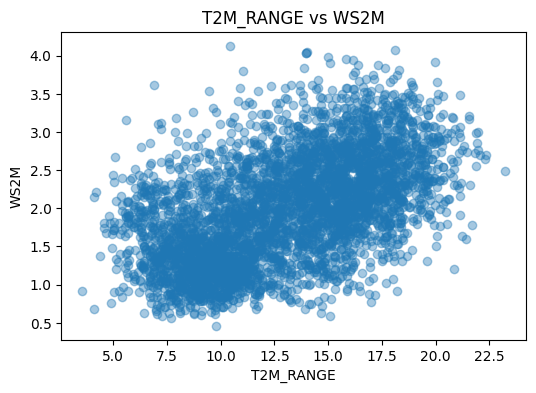

In [36]:
if "T2M_RANGE" not in df.columns:
    df["T2M_RANGE"] = df["T2M_MAX"] - df["T2M_MIN"]
plt.figure(figsize=(6, 4))
plt.scatter(df["T2M_RANGE"], df["WS2M"], alpha=0.4)
plt.xlabel("T2M_RANGE")
plt.ylabel("WS2M")
plt.title("T2M_RANGE vs WS2M")
plt.show()

In [37]:
corr_matrix = num_df.corr(numeric_only=True)
upper_triangle = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
top_corr = upper_triangle.stack().sort_values(key=np.abs, ascending=False).head(3)

print("Top 3 strongest correlations (absolute value):")
for (var_a, var_b), corr_val in top_corr.items():
    direction = "positive" if corr_val > 0 else "negative"
    print(f"{var_a} vs {var_b}: {corr_val:.3f} ({direction})")

Top 3 strongest correlations (absolute value):
DOY vs Month: 0.997 (positive)
WS2M vs WS2M_MAX: 0.941 (positive)
RH2M vs QV2M: 0.905 (positive)


### Correlation interpretation
Use the printed top-3 correlation pairs from this run to focus interpretation on the strongest relationships.
Calendar-linked variables are expected to correlate and should be interpreted as temporal structure rather than causal climate effects.
Wind-related correlations can indicate shared physical dynamics between baseline flow and stronger gust episodes.
Humidity-related correlations should be interpreted with atmospheric context, since moisture variables are often physically coupled.

## Distribution analysis
Look at the rainfall distribution, switch to a log view if it is strongly right-skewed, and then inspect the bubble chart.

PRECTOTCORR skewness: 3.17
Rainfall is heavily right-skewed; inspect the log histogram below.


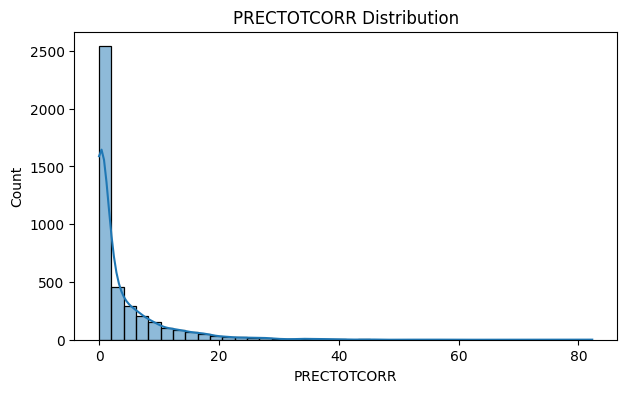

In [38]:
rain = df["PRECTOTCORR"].dropna()
rain_skew = rain.skew()
print(f"PRECTOTCORR skewness: {rain_skew:.2f}")
if rain_skew > 1:
    print("Rainfall is heavily right-skewed; inspect the log histogram below.")
elif rain_skew > 0.5:
    print("Rainfall is moderately right-skewed.")
else:
    print("Rainfall is near-symmetric or only mildly skewed.")

plt.figure(figsize=(7, 4))
sns.histplot(rain, bins=40, kde=True)
plt.title("PRECTOTCORR Distribution")
plt.show()

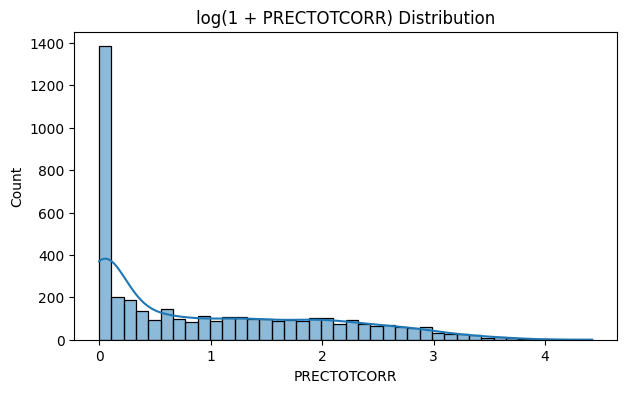

In [39]:
plt.figure(figsize=(7, 4))
sns.histplot(np.log1p(df["PRECTOTCORR"].dropna()), bins=40, kde=True)
plt.title("log(1 + PRECTOTCORR) Distribution")
plt.show()

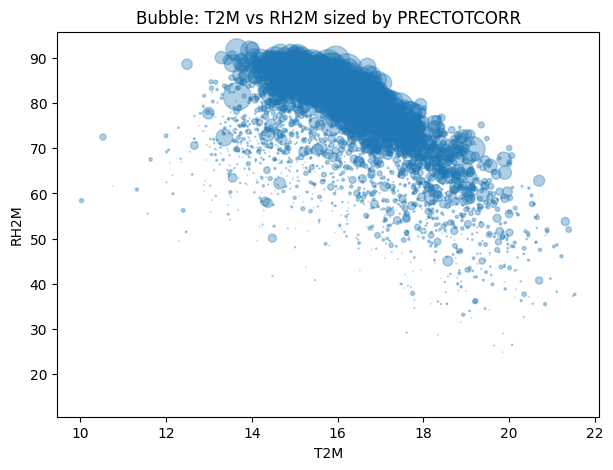

In [40]:
plt.figure(figsize=(7, 5))
size = df["PRECTOTCORR"].fillna(0).clip(lower=0) * 10
plt.scatter(df["T2M"], df["RH2M"], s=size, alpha=0.35)
plt.xlabel("T2M")
plt.ylabel("RH2M")
plt.title("Bubble: T2M vs RH2M sized by PRECTOTCORR")
plt.show()

### Distribution interpretation
Rainfall is typically right-skewed, with many low-precipitation days and fewer high-intensity events.
The log-transformed view helps reveal structure in low-to-moderate rainfall while reducing dominance from extreme events.
In the bubble chart, compare how precipitation event size varies across temperature and humidity regimes.

## References
- Pandas documentation: https://pandas.pydata.org/docs/
- NumPy documentation: https://numpy.org/doc/
- SciPy z-score reference: https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.zscore.html
- Matplotlib documentation: https://matplotlib.org/stable/users/index
- Seaborn documentation: https://seaborn.pydata.org/